In [30]:
%pip install -i https://test.pypi.org/simple/ argovisHelpers==0.0.34a5

Looking in indexes: https://test.pypi.org/simple/
  Attempting uninstall: argovisHelpers
    Found existing installation: argovisHelpers 0.0.34a4
    Uninstalling argovisHelpers-0.0.34a4:
      Successfully uninstalled argovisHelpers-0.0.34a4
Note: you may need to restart the kernel to use updated packages.


In [1]:
import xarray, numpy, math, scipy.interpolate, pandas
from argovisHelpers import helpers as avh
import matplotlib.pyplot as plt

API_ROOT = 'https://argovis-api.colorado.edu/'
API_KEY = 'guest'

# 1. Interpolations

Let's begin by downloading some Argo data as usual, and interpolating it to some standard levels with `interpolate_to_levels`. This interpolation scheme uses Scipy's pchip interpolator, with some opinionated filters:

 - Levels will only be interpolated to if they are inside the range of levels actually measured in the profile.
 - Interpolated levels will be masked as nan if the original profile doesn't have a measured level above and below the target level and sufficiently close to it. See `mask_for_interps` for the definition of 'sufficiently close'.
 - Interpolation will use the entire profile by default; see `pressure_buffer` and `pressure_index_buffer` args to interpolate over limited regions.

In [2]:
argo_qsp = {
    "polygon": [[-52.382812,53.225768],[-62.050781,48.107431],[-72.773438,43.325178],[-77.695313,37.996163],[-81.5625,32.990236],[-82.089844,27.683528],[-78.925781,22.755921],[-71.547389,23.008026],[-64.160156,22.917923],[-57.673458,28.712256],[-50.449219,34.161818],[-40.078125,44.590467],[-35.683594,51.618017],[-43.066406,54.265224],[-52.382812,53.225768]],
    "startDate": '2025-01-01T00:00:00Z',
    "endDate": '2025-02-01T00:00:00Z',
    "data": 'all'
}

argodata = avh.query('argo', argo_qsp, API_KEY, API_ROOT)

In [3]:
# choose an arbitrary profile, pick out pressure and a variable of interest, and use the helper to interpolate to a level spectrum.

pidx = 0
level_spectrum = [100,200,300,400,500]
p_idx = argodata[pidx]['data_info'][0].index('pressure')
t_idx = argodata[pidx]['data_info'][0].index('temperature')
raw_pressure = argodata[pidx]['data'][p_idx]
raw_temp = argodata[pidx]['data'][t_idx]

interp_temp, _ = avh.interpolate_to_levels(raw_pressure, raw_temp, level_spectrum)
print(interp_temp)

[16.054001   16.079      14.01518112 11.69631205  9.59968628]


Or, we can use `interpolate_all` to interpolate all the non-QC data found in the profile to our level spectrum:

In [4]:
avh.interpolate_all(argodata[pidx], [100,200,300,400,500])

{'_id': '3902458_078',
 'geolocation': {'type': 'Point',
  'coordinates': [-40.821331666666666, 44.45778]},
 'basin': 1,
 'timestamp': '2025-01-31T23:36:30.000Z',
 'date_updated_argovis': '2025-02-01T08:29:57.713Z',
 'source': [{'source': ['argo_core'],
   'url': 'ftp://ftp.ifremer.fr/ifremer/argo/dac/coriolis/3902458/profiles/R3902458_078.nc',
   'date_updated': '2025-02-01T00:32:02.000Z'}],
 'cycle_number': 78,
 'geolocation_argoqc': 1,
 'profile_direction': 'A',
 'timestamp_argoqc': 1,
 'vertical_sampling_scheme': 'Primary sampling: averaged [10 sec sampling, 5 dbar average from 2000 dbar to 1400 dbar; 10 sec sampling, 2 dbar average from 1400 dbar to 400 dbar; 10 sec sampling, 1 dbar average from 400 dbar to 5.0 dbar]',
 'data': [[100, 200, 300, 400, 500],
  [36.06864935746527,
   36.070999,
   35.77627802330296,
   35.44403217628436,
   35.193552952544565],
  [16.054001,
   16.079,
   14.015181118497262,
   11.69631204679539,
   9.599686279484946]],
 'data_info': [['pressure', 'sa

Finally, we can issue a query with `query_interpolated` to automatically interpolate profiles upon download. This helper takes the same routes and query string parameters as a regular query; if no level spectrum is provided, the Roemmich-Gilson Argo climatology levels are used by default:

In [5]:
qsp = {
    'platform': 4903575,
    'data': 'temperature,1,salinity,1'
}

interpolated_data = avh.query_interpolated('/argo', qsp)

In [6]:
interpolated_data

[{'_id': '4903575_070',
  'geolocation': {'type': 'Point', 'coordinates': [-169.169, 29.737]},
  'basin': 2,
  'timestamp': '2025-09-28T22:26:38.002Z',
  'date_updated_argovis': '2025-09-29T07:00:46.322Z',
  'source': [{'source': ['argo_core'],
    'url': 'ftp://ftp.ifremer.fr/ifremer/argo/dac/aoml/4903575/profiles/R4903575_070.nc',
    'date_updated': '2025-09-29T00:21:18.000Z'}],
  'cycle_number': 70,
  'geolocation_argoqc': 1,
  'profile_direction': 'A',
  'timestamp_argoqc': 1,
  'vertical_sampling_scheme': 'Primary sampling: mixed [deep: discrete, shallow: averaged]',
  'data': [[nan,
    27.085870777156252,
    27.087,
    27.022969367810386,
    21.948172688408512,
    20.88608326764987,
    19.711475157952925,
    19.269684214981893,
    18.731880671762138,
    18.1877746325247,
    17.419558629293114,
    16.805944475284768,
    16.547152698329057,
    16.30756380755518,
    16.161838037645463,
    15.917006636142736,
    15.729991048446202,
    15.420936575346184,
    15.2927

Note that if we attempt to interpolate outside of a reasonable range (outside the minimum and maximum measured levels, or too far from a measured level), the interpolation will fail and the profile will be suppressed:

In [7]:
interpolated_data = avh.query_interpolated('/argo', qsp, levels=[10000,11000,12000])
print(interpolated_data)

[]


Or, we can do the same thing as above using the `format_dataset` option, which will return the interpolated profiles as an xarray dimensioned on level:

In [8]:
interpolated_data = avh.query_interpolated('/argo', qsp, format_dataset=True)
interpolated_data

<xarray.Dataset>
Dimensions:      (nprof: 69, level: 58)
Coordinates:
    id           (nprof) <U11 '4903575_070' '4903575_069' ... '4903575_002'
    longitude    (nprof) float64 -169.2 -169.3 -169.4 ... -166.9 -166.8 -166.8
    latitude     (nprof) float64 29.74 29.6 29.48 29.43 ... 28.74 28.73 28.81
    timestamp    (nprof) datetime64[ns] 2025-09-28T22:26:38.002000 ... 2023-1...
Dimensions without coordinates: nprof, level
Data variables:
    pressure     (nprof, level) float64 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
    salinity     (nprof, level) float64 nan 35.47 35.47 ... 34.59 34.6 34.61
    temperature  (nprof, level) float64 nan 27.09 27.09 27.02 ... 2.13 2.02 1.95

Alternatively, we can also use the `audit_all` option to get back all the raw, uninterpolated profiles as well as all the interpolated profiles (whether the interpolation was possible or not):

In [9]:
audit_interpolated, audit_raw = avh.query_interpolated('/argo', qsp, audit_all=True)
print(audit_raw[0])
print(audit_interpolated[0])

{'_id': '4903575_070', 'geolocation': {'type': 'Point', 'coordinates': [-169.169, 29.737]}, 'basin': 2, 'timestamp': '2025-09-28T22:26:38.002Z', 'date_updated_argovis': '2025-09-29T07:00:46.322Z', 'source': [{'source': ['argo_core'], 'url': 'ftp://ftp.ifremer.fr/ifremer/argo/dac/aoml/4903575/profiles/R4903575_070.nc', 'date_updated': '2025-09-29T00:21:18.000Z'}], 'cycle_number': 70, 'geolocation_argoqc': 1, 'profile_direction': 'A', 'timestamp_argoqc': 1, 'vertical_sampling_scheme': 'Primary sampling: mixed [deep: discrete, shallow: averaged]', 'data': [[27.091, 27.091999, 27.084999, 27.086, 27.086, 27.086, 27.086, 27.087, 27.087, 27.087, 27.089001, 27.066, 27.049, 26.993, 24.907, 23.186001, 22.614, 22.278999, 21.872999, 21.375999, 21.18, 21.052999, 20.919001, 20.877001, 20.827, 20.570999, 20.343, 19.979, 19.667, 19.586, 19.562, 19.507, 19.382, 19.233999, 19.055, 18.985001, 18.855, 18.775999, 18.716, 18.596001, 18.486, 18.445999, 18.354, 18.132999, 17.889, 17.712, 17.587999, 17.530001,

# 2. Grids & timeseries in xarray

Use the `datagrid` helper to download gridded or timeseries data and automatically load it into an xarray dataset dimensioned by longitude, latitude, time and level. Pass routes and query string parameters just as you would a normal `query`:

In [10]:
griddata_qsp = {
    "polygon": [[-52.382812,53.225768],[-62.050781,48.107431],[-72.773438,43.325178],[-77.695313,37.996163],[-81.5625,32.990236],[-82.089844,27.683528],[-78.925781,22.755921],[-71.547389,23.008026],[-64.160156,22.917923],[-57.673458,28.712256],[-50.449219,34.161818],[-40.078125,44.590467],[-35.683594,51.618017],[-43.066406,54.265224],[-52.382812,53.225768]],
    "startDate": '2024-01-01T00:00:00Z',
    "endDate": '2025-01-01T00:00:00Z',
    "verticalRange": [0,1000],
    "data": 'all'
}

xar = avh.datagrid('grids/rg09', griddata_qsp, API_KEY, API_ROOT)

In [11]:
xar

<xarray.Dataset>
Dimensions:           (timestamp: 12, longitude: 44, latitude: 31, level: 43)
Coordinates:
  * timestamp         (timestamp) datetime64[ns] 2024-01-15 ... 2024-12-15
  * longitude         (longitude) float64 -79.5 -78.5 -77.5 ... -37.5 -36.5
  * latitude          (latitude) float64 23.5 24.5 25.5 26.5 ... 51.5 52.5 53.5
  * level             (level) float64 2.5 10.0 20.0 30.0 ... 850.0 900.0 950.0
Data variables:
    rg09_salinity     (timestamp, longitude, latitude, level) float64 nan ......
    rg09_temperature  (timestamp, longitude, latitude, level) float64 nan ......

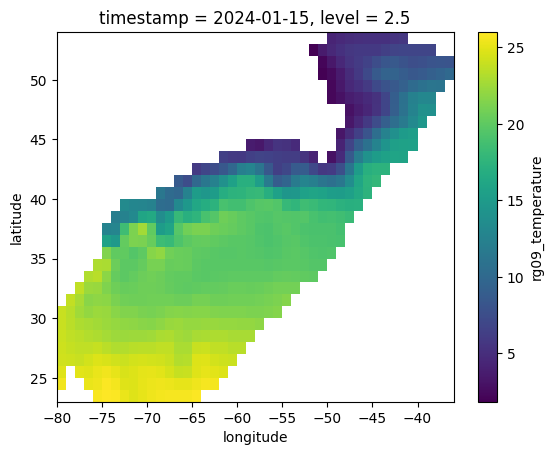

In [12]:
xar["rg09_temperature"].isel(timestamp=0, level=0).plot(x='longitude', y='latitude') 

Once downloaded in xarray Dataset format, we can easily calculate statistics like area weighted means:

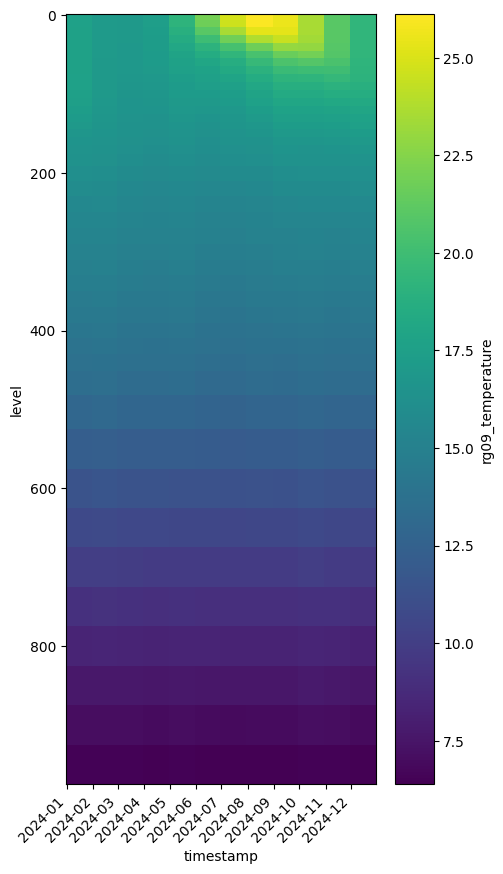

In [15]:
xar_regional_mean = avh.regional_mean(xar, form='area')
ax = xar_regional_mean['rg09_temperature'].plot(y="level",yincrease=False,aspect=0.5, size=10)
plt.xticks(rotation=45, ha="right")
plt.show()


Similarly, timeseries data is available in xarray format:

In [16]:
tsdata_qsp = {
    "polygon": [[-40,-40],[-40,-30],[-30,-30],[-30,-40],[-40,-40]],
    "startDate": "1993-01-09T00:00:00Z",
    "endDate": "1993-01-11T00:00:00Z",
    "data": 'all'
}

ts_xar = avh.datagrid('timeseries/ccmpwind', tsdata_qsp, API_KEY, API_ROOT, verbose=True)

https://argovis-api.colorado.edu/timeseries/ccmpwind?polygon=[[-40,+-40],+[-40,+-30],+[-30,+-30],+[-30,+-40],+[-40,+-40]]&startDate=1993-01-09T00:00:00Z&endDate=1993-01-11T00:00:00Z&data=all
https://argovis-api.colorado.edu/timeseries/ccmpwind?polygon=[[-40,+-40],+[-40,+-30],+[-30,+-30],+[-30,+-40],+[-40,+-40]]&startDate=1993-01-09T00:00:00Z&endDate=1993-01-11T00:00:00Z&data=all&batchmeta=True


In [17]:
ts_xar

<xarray.Dataset>
Dimensions:    (timestamp: 1, longitude: 40, latitude: 40, level: 1)
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 1993-01-10
  * longitude  (longitude) float64 -39.88 -39.62 -39.38 ... -30.62 -30.38 -30.12
  * latitude   (latitude) float64 -39.88 -39.62 -39.38 ... -30.62 -30.38 -30.12
  * level      (level) int64 0
Data variables:
    nobs       (timestamp, longitude, latitude, level) float64 14.0 ... 12.0
    uwnd       (timestamp, longitude, latitude, level) float64 6.644 ... 2.717
    vwnd       (timestamp, longitude, latitude, level) float64 -0.8013 ... -3...
    ws         (timestamp, longitude, latitude, level) float64 8.592 ... 6.431

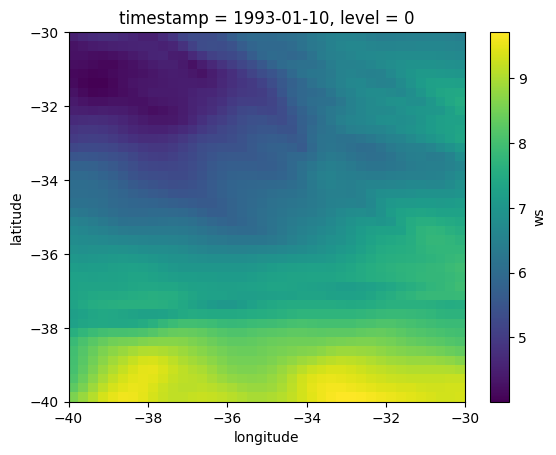

In [18]:
ts_xar["ws"].isel(timestamp=0, level=0).plot(x='longitude', y='latitude') 

We can also do some meridional and zonal averages with the same helper:

In [19]:
ts_mer = avh.regional_mean(ts_xar, form='meridional')

In [20]:
ts_mer

<xarray.Dataset>
Dimensions:    (timestamp: 1, longitude: 40, level: 1)
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 1993-01-10
  * longitude  (longitude) float64 -39.88 -39.62 -39.38 ... -30.62 -30.38 -30.12
  * level      (level) int64 0
Data variables:
    nobs       (timestamp, longitude, level) float64 12.5 12.47 ... 10.87 10.38
    uwnd       (timestamp, longitude, level) float64 3.247 3.306 ... 5.028 5.096
    vwnd       (timestamp, longitude, level) float64 -1.488 -1.498 ... -2.103
    ws         (timestamp, longitude, level) float64 6.187 6.232 ... 7.539 7.57

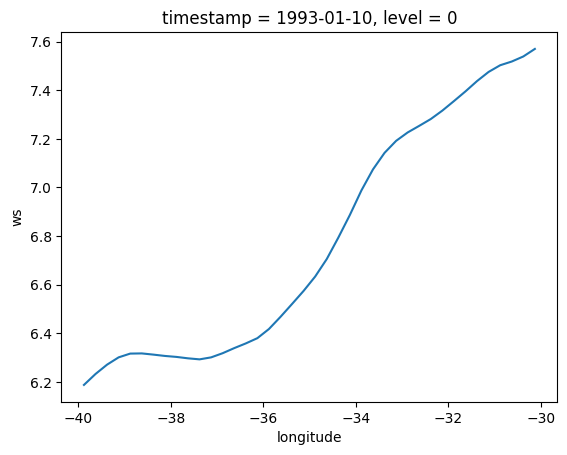

In [21]:
ts_mer.sel(level=0)['ws'].plot()

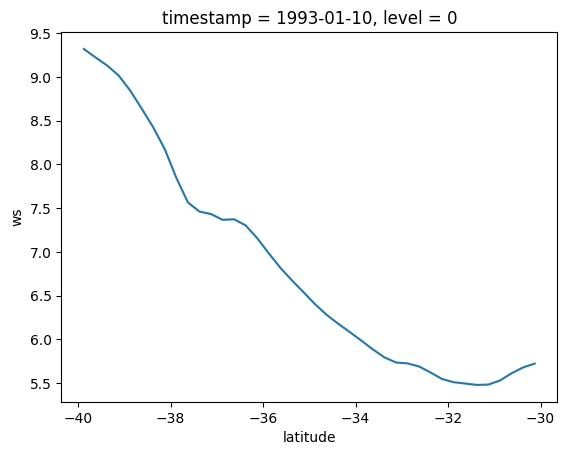

In [22]:
ts_zon = avh.regional_mean(ts_xar, form='zonal')
ts_zon.sel(level=0)['ws'].plot()